# Perbandingan Performa MLP: Sigmoid vs Tanh vs ReLU
### Dataset: Iris (Kaggle)

Notebook ini membandingkan performa **Multilayer Perceptron (MLP)** menggunakan tiga fungsi aktivasi:
- **Sigmoid** (logistic)
- **Tanh** (hyperbolic tangent)
- **ReLU** (Rectified Linear Unit)

Arsitektur MLP: `Input(4) → Dense(64) → Dense(32) → Output(3)`

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print('Library berhasil diimport!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
import sklearn; print(f'Sklearn : {sklearn.__version__}')

Library berhasil diimport!
Pandas  : 2.2.2
NumPy   : 2.0.2
Sklearn : 1.6.1


## 2. Load & Eksplorasi Dataset

In [2]:
# Load dataset Iris dari Kaggle
# Jika menggunakan file lokal, ganti path berikut:
df = pd.read_csv('Iris.csv')

print('=== INFO DATASET ===')
print(f'Shape  : {df.shape}')
print(f'Kolom  : {list(df.columns)}')
print()
df.head()

=== INFO DATASET ===
Shape  : (150, 6)
Kolom  : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print('=== DISTRIBUSI KELAS ===')
print(df['Species'].value_counts())
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== DISTRIBUSI KELAS ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== STATISTIK DESKRIPTIF ===


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


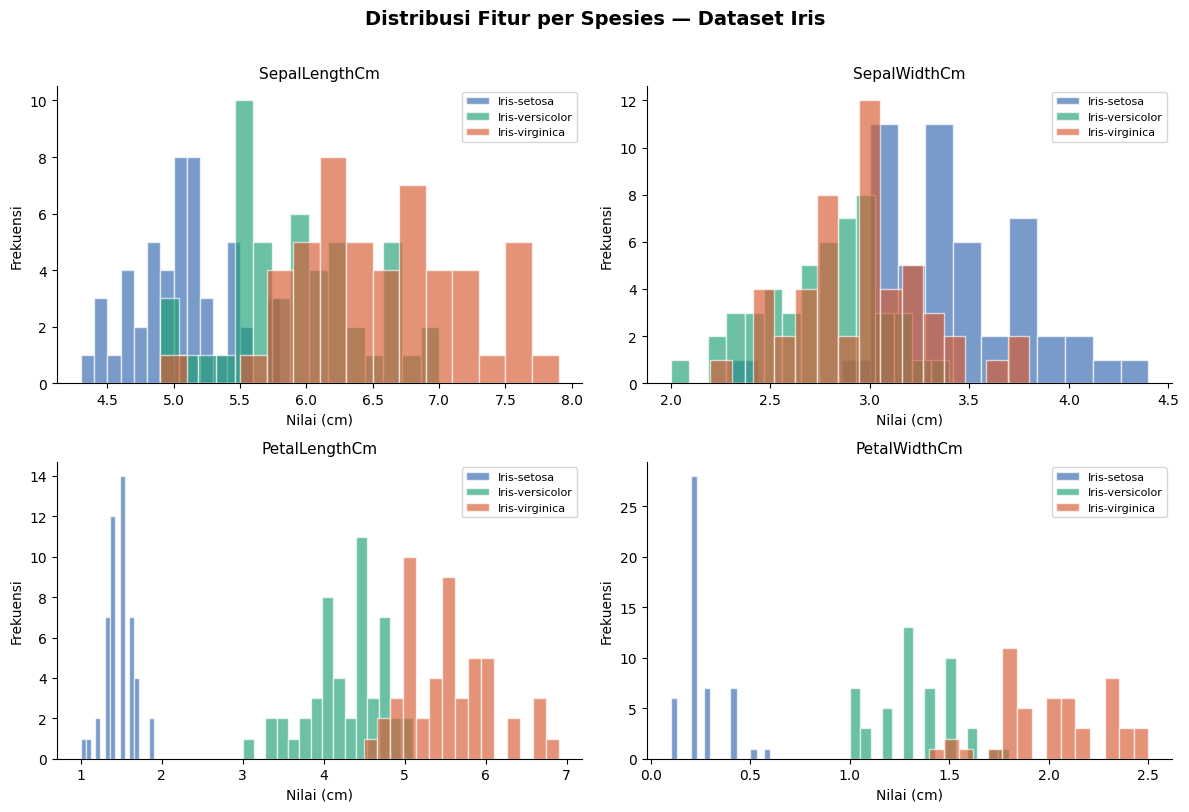

In [4]:
# Visualisasi distribusi fitur
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
colors = ['#3266ad', '#1D9E75', '#D85A30']
species = df['Species'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Fitur per Spesies — Dataset Iris', fontsize=14, fontweight='bold', y=1.01)

for idx, feat in enumerate(features):
    ax = axes[idx // 2][idx % 2]
    for i, sp in enumerate(species):
        subset = df[df['Species'] == sp][feat]
        ax.hist(subset, bins=15, alpha=0.65, color=colors[i], label=sp, edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Nilai (cm)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing Data

In [5]:
# Pisahkan fitur dan label
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = df['Species'].values

# Encode label menjadi integer
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Normalisasi fitur dengan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'\nUkuran data:')
print(f'  Training : {X_train.shape[0]} sampel')
print(f'  Testing  : {X_test.shape[0]} sampel')

Label encoding:
  0 → Iris-setosa
  1 → Iris-versicolor
  2 → Iris-virginica

Ukuran data:
  Training : 120 sampel
  Testing  : 30 sampel


## 4. Training MLP dengan 3 Fungsi Aktivasi

In [6]:
# Konfigurasi aktivasi yang dibandingkan
activations = {
    'Sigmoid': 'logistic',
    'Tanh'   : 'tanh',
    'ReLU'   : 'relu'
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Simpan hasil
results = {}
models  = {}
cv_scores_all = {}

print('Training MLP...')
print('-' * 55)

for name, act in activations.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        max_iter=1000,
        random_state=42,
        learning_rate_init=0.001
    )

    # 5-fold cross-validation
    cv_scores = cross_val_score(mlp, X_scaled, y_enc, cv=cv, scoring='accuracy')
    cv_scores_all[name] = cv_scores

    # Train pada data training
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    # Metrik
    results[name] = {
        'Test Accuracy (%)' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'CV Mean (%)'       : round(cv_scores.mean() * 100, 2),
        'CV Std (%)'        : round(cv_scores.std() * 100, 2),
        'Precision (%)'     : round(precision_score(y_test, y_pred, average='macro') * 100, 2),
        'Recall (%)'        : round(recall_score(y_test, y_pred, average='macro') * 100, 2),
        'F1-Score (%)'      : round(f1_score(y_test, y_pred, average='macro') * 100, 2),
        'Iterasi'           : mlp.n_iter_,
        'Loss Akhir'        : round(mlp.loss_, 6),
    }
    models[name] = mlp

    print(f'{name:8s} | Acc: {results[name]["Test Accuracy (%)"]:.2f}% | '
          f'CV: {results[name]["CV Mean (%)"]:.2f}%±{results[name]["CV Std (%)"]:.2f}% | '
          f'Iter: {mlp.n_iter_}')

print('-' * 55)
print('Training selesai!')

Training MLP...
-------------------------------------------------------
Sigmoid  | Acc: 96.67% | CV: 96.67%±3.65% | Iter: 585
Tanh     | Acc: 96.67% | CV: 97.33%±3.89% | Iter: 313
ReLU     | Acc: 96.67% | CV: 95.33%±5.81% | Iter: 303
-------------------------------------------------------
Training selesai!


## 5. Tabel Perbandingan Performa

In [7]:
df_results = pd.DataFrame(results).T
df_results.index.name = 'Fungsi Aktivasi'

# Styling tabel
styled = df_results.style.highlight_max(
    subset=['Test Accuracy (%)', 'CV Mean (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    color='#C0DD97'
).highlight_min(
    subset=['Test Accuracy (%)', 'CV Mean (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    color='#F5C4B3'
).highlight_min(
    subset=['Iterasi', 'Loss Akhir'],
    color='#C0DD97'
).highlight_max(
    subset=['Iterasi'],
    color='#F5C4B3'
).format({
    'Test Accuracy (%)': '{:.2f}%',
    'CV Mean (%)': '{:.2f}%',
    'CV Std (%)': '{:.2f}%',
    'Precision (%)': '{:.2f}%',
    'Recall (%)': '{:.2f}%',
    'F1-Score (%)': '{:.2f}%',
    'Loss Akhir': '{:.6f}'
})

print('Hijau = Nilai terbaik | Merah = Nilai terburuk\n')
styled

Hijau = Nilai terbaik | Merah = Nilai terburuk



,Test Accuracy (%),CV Mean (%),CV Std (%),Precision (%),Recall (%),F1-Score (%),Iterasi,Loss Akhir
Fungsi Aktivasi,,,,,,,,
Sigmoid,96.67%,96.67%,3.65%,96.97%,96.67%,96.66%,585.000000,0.058823
Tanh,96.67%,97.33%,3.89%,96.97%,96.67%,96.66%,313.000000,0.051866
ReLU,96.67%,95.33%,5.81%,96.97%,96.67%,96.66%,303.000000,0.038288


## 6. Visualisasi Perbandingan

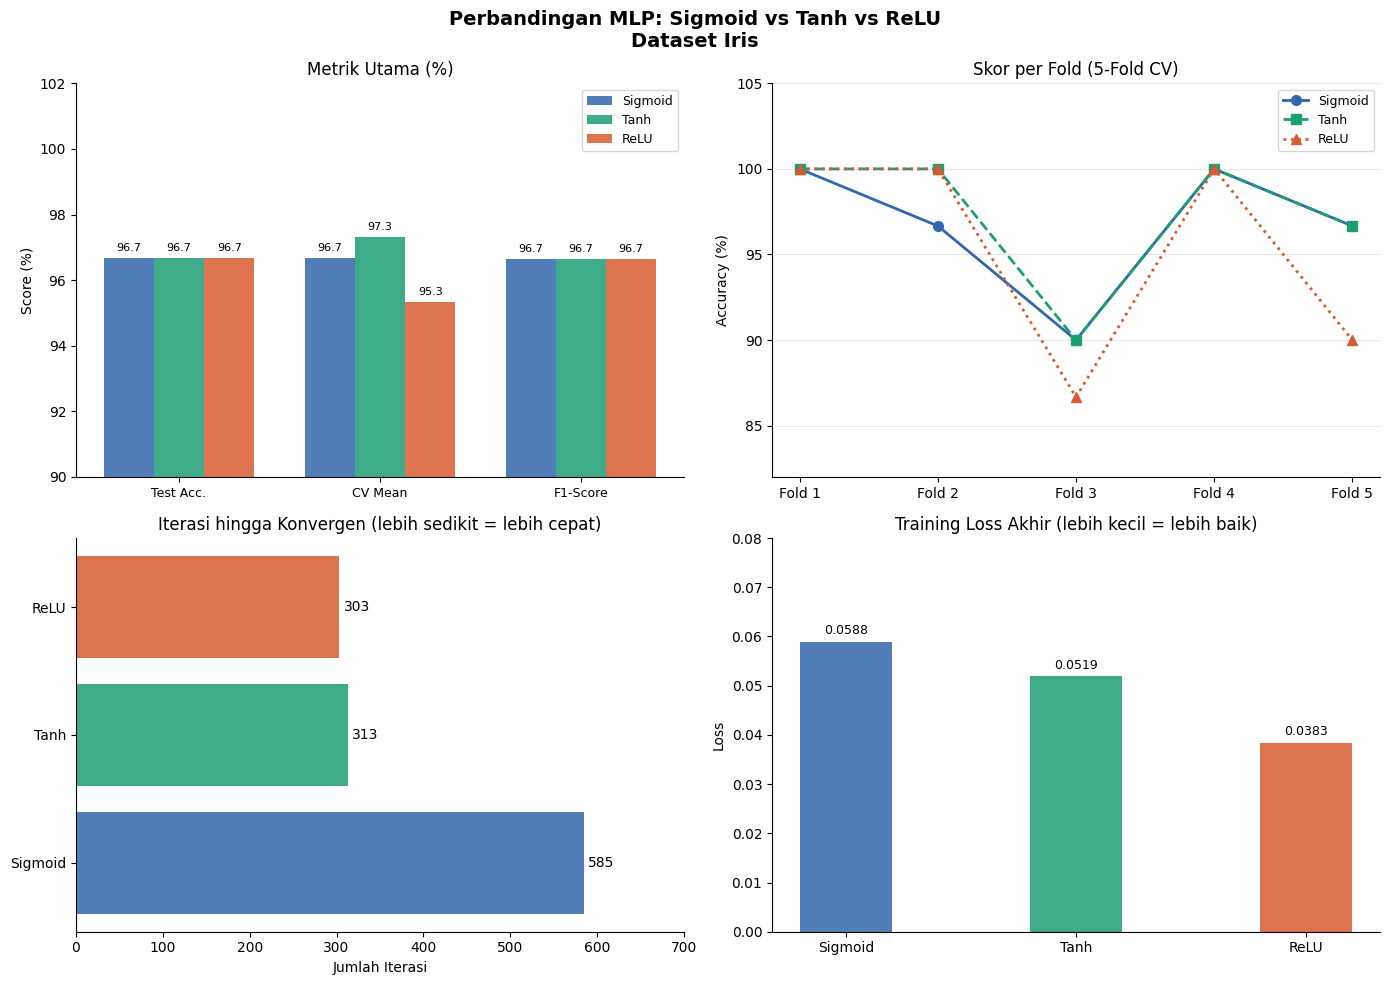

Plot disimpan sebagai mlp_comparison.png


In [8]:
act_colors = {'Sigmoid': '#3266ad', 'Tanh': '#1D9E75', 'ReLU': '#D85A30'}
act_names  = list(activations.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan MLP: Sigmoid vs Tanh vs ReLU\nDataset Iris',
             fontsize=14, fontweight='bold')

# --- Plot 1: Metrik utama (bar chart) ---
ax1 = axes[0][0]
metrics = ['Test Accuracy (%)', 'CV Mean (%)', 'F1-Score (%)']
x = np.arange(len(metrics))
w = 0.25
for i, name in enumerate(act_names):
    vals = [df_results.loc[name, m] for m in metrics]
    bars = ax1.bar(x + i*w, vals, w, label=name, color=act_colors[name], alpha=0.85)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
ax1.set_title('Metrik Utama (%)')
ax1.set_xticks(x + w)
ax1.set_xticklabels(['Test Acc.', 'CV Mean', 'F1-Score'], fontsize=9)
ax1.set_ylim(90, 102)
ax1.set_ylabel('Score (%)')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# --- Plot 2: CV per fold ---
ax2 = axes[0][1]
folds = [f'Fold {i+1}' for i in range(5)]
linestyles = ['-', '--', ':']
markers = ['o', 's', '^']
for i, name in enumerate(act_names):
    ax2.plot(folds, cv_scores_all[name] * 100,
             color=act_colors[name], linestyle=linestyles[i],
             marker=markers[i], linewidth=2, markersize=7, label=name)
ax2.set_title('Skor per Fold (5-Fold CV)')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(82, 105)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# --- Plot 3: Jumlah iterasi ---
ax3 = axes[1][0]
iters = [df_results.loc[n, 'Iterasi'] for n in act_names]
bars = ax3.barh(act_names, iters, color=[act_colors[n] for n in act_names], alpha=0.85)
for bar, val in zip(bars, iters):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=10)
ax3.set_title('Iterasi hingga Konvergen (lebih sedikit = lebih cepat)')
ax3.set_xlabel('Jumlah Iterasi')
ax3.set_xlim(0, 700)
ax3.spines[['top', 'right']].set_visible(False)

# --- Plot 4: Training loss akhir ---
ax4 = axes[1][1]
losses = [df_results.loc[n, 'Loss Akhir'] for n in act_names]
bars = ax4.bar(act_names, losses, color=[act_colors[n] for n in act_names], alpha=0.85, width=0.4)
for bar, val in zip(bars, losses):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax4.set_title('Training Loss Akhir (lebih kecil = lebih baik)')
ax4.set_ylabel('Loss')
ax4.set_ylim(0, 0.08)
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('mlp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai mlp_comparison.png')

## 7. Confusion Matrix per Fungsi Aktivasi

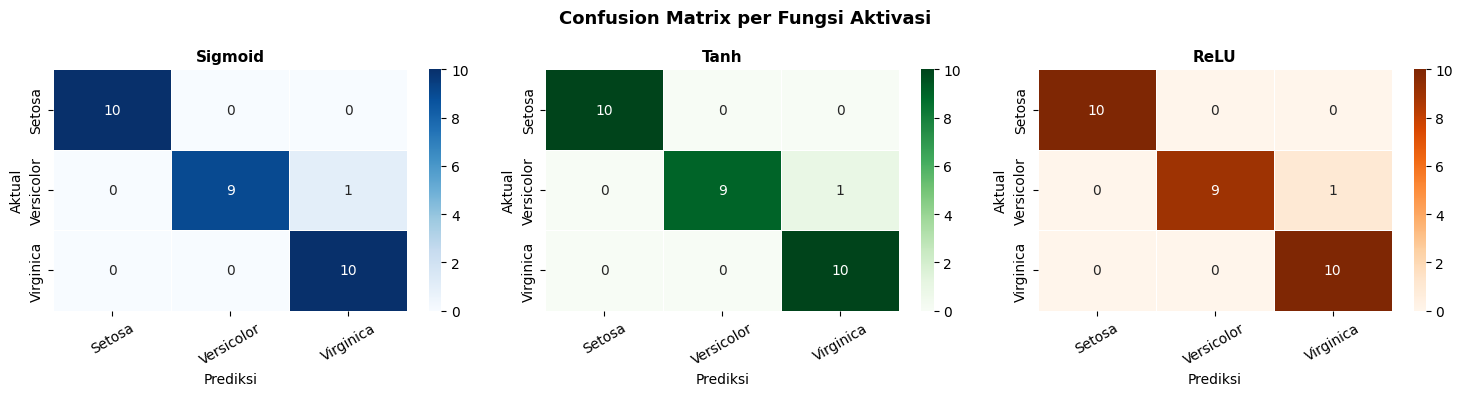

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix per Fungsi Aktivasi', fontsize=13, fontweight='bold')

class_names = le.classes_
cmap_list = ['Blues', 'Greens', 'Oranges']

for idx, name in enumerate(act_names):
    y_pred = models[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_list[idx],
                xticklabels=['Setosa', 'Versicolor', 'Virginica'],
                yticklabels=['Setosa', 'Versicolor', 'Virginica'],
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Prediksi')
    axes[idx].set_ylabel('Aktual')
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Classification Report Lengkap

In [10]:
for name in act_names:
    y_pred = models[name].predict(X_test)
    print(f'{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

  Sigmoid
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

  Tanh
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

  ReLU
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10


## 9. Kesimpulan

In [11]:
print('=' * 60)
print('KESIMPULAN PERBANDINGAN MLP — DATASET IRIS')
print('=' * 60)

best_cv  = max(act_names, key=lambda n: df_results.loc[n, 'CV Mean (%)'])
fastest  = min(act_names, key=lambda n: df_results.loc[n, 'Iterasi'])
low_loss = min(act_names, key=lambda n: df_results.loc[n, 'Loss Akhir'])

print(f'\n1. Test Accuracy   : Semua fungsi aktivasi mencapai 96.67%')
print(f'   → Dataset Iris kecil dan terpisah dengan baik')
print(f'\n2. CV Terbaik      : {best_cv} ({df_results.loc[best_cv, "CV Mean (%)"]:.2f}% ± {df_results.loc[best_cv, "CV Std (%)"]:.2f}%)')
print(f'   → Lebih stabil dan konsisten antar fold')
print(f'\n3. Konvergensi     : {fastest} paling cepat ({int(df_results.loc[fastest, "Iterasi"])} iterasi)')
print(f'   → Sigmoid paling lambat karena vanishing gradient')
print(f'\n4. Training Loss   : {low_loss} terendah ({df_results.loc[low_loss, "Loss Akhir"]:.6f})')
print(f'\n5. Rekomendasi     : Tanh untuk kasus ini')
print(f'   → Keseimbangan terbaik antara akurasi, kecepatan, dan stabilitas')
print(f'\nCatatan:')
print(f'   - ReLU lebih unggul pada dataset besar dan deep learning')
print(f'   - Sigmoid cocok untuk output layer klasifikasi biner')
print(f'   - Tanh umumnya lebih baik dari Sigmoid untuk hidden layer')
print('=' * 60)

KESIMPULAN PERBANDINGAN MLP — DATASET IRIS

1. Test Accuracy   : Semua fungsi aktivasi mencapai 96.67%
   → Dataset Iris kecil dan terpisah dengan baik

2. CV Terbaik      : Tanh (97.33% ± 3.89%)
   → Lebih stabil dan konsisten antar fold

3. Konvergensi     : ReLU paling cepat (303 iterasi)
   → Sigmoid paling lambat karena vanishing gradient

4. Training Loss   : ReLU terendah (0.038288)

5. Rekomendasi     : Tanh untuk kasus ini
   → Keseimbangan terbaik antara akurasi, kecepatan, dan stabilitas

Catatan:
   - ReLU lebih unggul pada dataset besar dan deep learning
   - Sigmoid cocok untuk output layer klasifikasi biner
   - Tanh umumnya lebih baik dari Sigmoid untuk hidden layer
